#### First Step: Import Libraries
- import numpy, pandas, matplotlib, KNeighborsClassifier from sklearn.neighbors and some metrics

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#### Second Step: Read csv file
- read the csv file data using pd (pandas)

In [49]:
df = pd.read_csv("car.csv")

#### Third Step: Preview Data
- preview the first 5 rows of data to see the type of the data like categorical and numerical
- also to see the type of output column if discrete or continuous

In [50]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#### Fourth Step: Initialize X
- X is only the input data without the output column

In [51]:
X = df.drop(columns=["diagnosis"], axis=1)
X

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


#### Fifth Step: Initialize Y
- y is only the output column

In [52]:
y = df["diagnosis"]
y

0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, Length: 569, dtype: object

#### Sixth Step: Import and Initialize transformers
- based on the data:
    - if we have categorical data import OneHotEncoder to transform them to numerical
    - if we have numerical data import StandardScaler to scale values (so no feature is dominant over the others)

In [53]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numerical_transfomer = StandardScaler()
hot_transfomer = OneHotEncoder(handle_unknown="ignore",sparse_output=True)

preprocessor = ColumnTransformer ([
    ("OneHotEncoder", hot_transfomer, cat_features),
    ("StandardScalar", numerical_transfomer, num_features)
])

#### Seventh Step: fit transform X
- the input must be fit transformed using the transformers to apply transformation
- here we will apply the note that to scale after splitting: fit transform for X_train and transform for X_test

In [54]:
# X = preprocessor.fit_transform(X)

#### Eighth Step: split data into training and testing
- we must split data into training and testing
- as a some standards way:
    - training 80%, testing 20%
    - training 70%, testing 30%

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42,shuffle=True)

#### Ninth Step: Better than step 7 (either step 7 either this)

- **but you can skip it now for the hackathon and do 7**

- it is better to transform training and testing like this below instead of fit transform all X 
    - fit transform all X is not a good idea, because the model will see the whole X training and testing
    - fit transform all X can lead to data leakage because:
        - fit_transform calculates the parameters (like mean and variance) from the data and applies the transformation in one step, whereas transform uses those previously learned parameters to transform new data consistently.
    - so we apply fit transform on X_train and transform on X_test

- **Note: Of course you must do transforming but either 7 or 9**

In [56]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

#### This is to show you how to do KNN choosing a specific number of neighbors
**Of course we must iterate over k like below and choose the best**

In [57]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, Y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


##### **Accuracy:** Number of total correct predictions the model got over all predictions.

In [58]:
y_pred = knn.predict(X_test)

accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


##### **Confusion Matrix:** Table showing correct vs. incorrect predictions for each class.

In [59]:
confusion_matrix(Y_test, y_pred)

array([[68,  3],
       [ 3, 40]])

##### **Classification Report:** Summary of precision, recall, F1-score, and support for each class.
- Precision: Of all predicted positives, how many were actually correct.
- Recall: Of all actual positives, how many the model correctly identified.
- F1-score: Harmonic mean of precision and recall, balancing both.
- Support: Number of actual samples for each class in the dataset.

In [60]:
print(classification_report(Y_test, y_pred))


              precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



#### Tenth Step: Best way to choose the number of nearest neighbors
1. loop over k from 1 to 21
2. apply KNeighborsClassifier on k
3. fit the model
4. predict using X_test
5. check accuracy
6. add accuracy to the array

In [61]:
k_values = range(1, 22)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    accuracies.append(acc)


#### Eleventh Step: Choose best k
1. find best k using maximum accuracy
2. get the best accuracy

In [62]:
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

#### Twelfth Step: Plot the figure of k
- plot the accuracy of each k and highlight the best

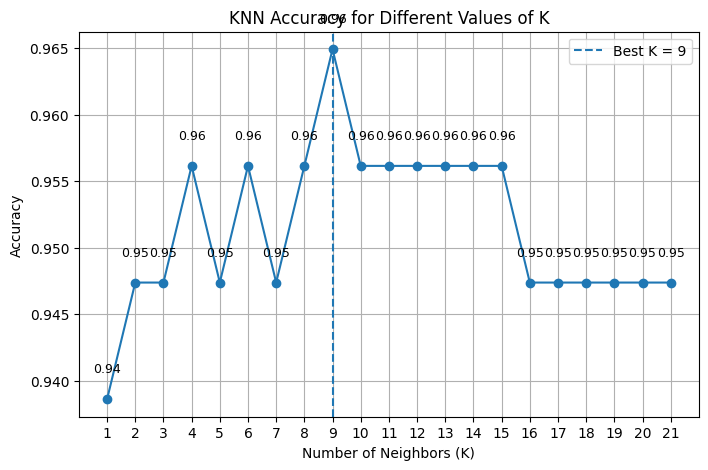

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.axvline(best_k, linestyle='--', label=f'Best K = {best_k}')

# show accuracy values on the plot
for k, acc in zip(k_values, accuracies):
    plt.text(k, acc + 0.002, f"{acc:.2f}", ha='center', fontsize=9)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different Values of K")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

In [64]:
print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 9
Best Accuracy: 0.9649122807017544


#### Thirteenth Step: train the model using the best k

In [65]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Fourteenth Step: predict using X_test and print metrics

In [66]:
y_pred_best = knn_best.predict(X_test)

print("Final Model Accuracy:", accuracy_score(Y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_best))

Final Model Accuracy: 0.9649122807017544

Confusion Matrix:
 [[69  2]
 [ 2 41]]

Classification Report:
               precision    recall  f1-score   support

           B       0.97      0.97      0.97        71
           M       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



#### Fifteenth Step: Save actual and Predicted values into a csv file

In [67]:
pred_df = pd.DataFrame({"Actual":Y_test, "Predicted":y_pred_best})
pred_df.to_csv("car_actual_vs_predicted_knn.csv", index=False)
pred_df

,Actual,Predicted
204,B,B
70,M,M
131,M,M
431,B,B
540,B,B
...,...,...
486,B,B
75,M,M
249,B,B
238,B,B


#### Sixteenth Step: Try a new unseen data
1. declare the data using array
2. Initialize X_df without target because it contains the columns names before scaling
3. Initialize new_car_df with the new data and columns names
4. transform the new_car_df
5. predict the target
6. print result either acc, unacc, good, vgood

In [68]:
# 1. Provide the new car data (matching the categorical values in the dataset)
# Order: [Price, Maintenance Cost, Doors, Persons, Luggage Boot, Security]
new_car = [50000, "vhigh", "4", "more", "big", "high"]

# 2. Setup X_df to get the correct column names for the DataFrame
X_df = df.drop("Acceptablity", axis=1)

# 3. Create a DataFrame for the new car
new_car_df = pd.DataFrame(
    [new_car],
    columns=X_df.columns
)

# 4. Transform the data using the SAME preprocessor used during training
new_car_scaled = preprocessor.transform(new_car_df)

# 5. Use the best KNN model to predict
prediction = knn_best.predict(new_car_scaled)

# 6. Print the result (Acceptability: unacc, acc, good, or vgood)
print(f"Prediction: {prediction[0]}")

KeyError: "['Acceptablity'] not found in axis"

In [ ]:
import joblib
joblib.dump(knn_best, "knn_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")